# Attribution of weather features to precipitation in Victoria, Australia

Preliminary analysis for attribution of precipitation to weather features, cyclones (surface), fronts and moisture transport axes (MTAs; similar to atmospheric rivers), following Konstali et al. (2024). We include cyclones at 500 hPa and exclude cold air outbreaks (CAO) because CAOs only occur over the ocean and have been found not to contribute much rainfall around Victoria (Konstali et al., 2024). 

This analysis is based on an example notebook provided by Michael Barnes. 

## Software
- Based on ACCESS-NRI's NCI xp65 anaylsis3-25.11 conda environment
- Uses  M. Barnes local installation of dynlib
    - https://folk.uib.no/csp001/dynlib_doc/
    - https://git.app.uib.no/Clemens.Spensberger/dynlib/-/blob/master/

## Data
- ERA5 total precipitation (tp) and geopotential for cyclone detection (project rt52 on NCI)
    - https://confluence.ecmwf.int/spaces/CKB/pages/76414402/ERA5+data+documentation
- EAR5 weather objects (cyclones, fronts, MTAs; see references)
- Cyclones at 500 hPa generated using detect_cyclones.py

## References
- Spensberger, C. (2023). ERA5 jet axes 1979-2022 [Data set]. NIRD RDA. https://doi.org/10.11582/2023.00120
- Spensberger, C., Marcheggiani, A. (2024). ERA5 cyclone tracks [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00023
- Spensberger, C. (2024). ERA5 cyclones, anticyclones, fronts and cold-air outbreaks [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00095 
- Spensberger, C. (2024). ERA5 moisture transport axis detections [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00178
- Konstali, K., C. Spensberger, T. Spengler, and A. Sorteberg, 2024: Global Attribution of Precipitation to Weather Features. J. Climate, 37, 1181–1196, https://doi.org/10.1175/JCLI-D-23-0293.1.

In [1]:
# Import local dynlib (not sure if all necessary, but it works)
import os
import sys
import importlib.util

pkg_dir = "/g/data/xv83/mb0427/dynlib-1.6.1.dev7+g2e093da-py3.11.egg"
wxsys_dir = "/g/data/gb02/mb0427/WxSysLib"

os.environ["WXSYSLIBDIR"] = wxsys_dir
os.environ["DYNLIBDIR"] = pkg_dir

sys.path.insert(0, pkg_dir)
sys.path.insert(0, wxsys_dir)

importlib.invalidate_caches()

import dynlib
from dynlib import utils, gridlib, dynfor, detect

In [2]:
import calendar
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LatitudeFormatter, LongitudeFormatter
import cmaps
from datetime import datetime, timedelta
from dask.distributed import Client
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from tqdm import tqdm
import xarray as xr

# from xclim.core import units

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43637,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43995,Total threads: 1
Dashboard: /proxy/34029/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:37205,


In [4]:
# path_obj = "/g/data/xv83/mb0427/VicWaCI/data/bergen_obj"
path_features = "/g/data/xv83/as3189/vicwaci/data/weather_features"
path_fig = "/g/data/xv83/as3189/vicwaci/figures/weather_features/"
path_attr = "/g/data/xv83/as3189/vicwaci/data/precip_attribution"

lat_slice, lon_slice = slice(-5, -65), slice(90, 180)

In [ ]:
var_map = dict(
    F="Fronts only",
    M="MTAs only",
    C="Cyclones only (surface)",
    V="Cyclones only (500 hPa)",
    FM="Fronts and MTAs",
    CF="Fronts and Cyclones (surface)",
    VF="Fronts and Cyclones (500 hPa)",
    CV="Cyclones (surface & 500 hPa)",
    CM="MTAs and Cyclones (surface)",
    VM="MTAs and Cyclones (500 hPa)",
    CVF="Fronts and Cyclones (surface & 500 hPa)",
    CVM="MTAs and Cyclones (surface & 500 hPa)",
    CFM="Fronts, MTAs and Cyclones (surface)",
    VFM="Fronts, MTAs and Cyclones (500 hPa)",
    CVFM="Fronts, MTAs and Cyclones (surface & 500 hPa)",
    # U="Unclassified",
)
wf_map = dict(
    F="Fronts",
    M="MTAs",
    C="Cyclones (surface)",
    V="Cyclones (500 hPa)",
    U="Unclassified",
)
len(var_map)

15

In [6]:
# %%time
# # lat_slice, lon_slice = slice(-30, -45), slice(135, 155)
# # da = ds.sel(latitude=lat_slice, longitude=lon_slice)
# ds.attrs["history"] = ds.attrs["history"] + f"\n{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Combined timesteps and subset to region around Victoria, Australia."
# # var_encoding = {"zlib": True, "complevel": 4}
# # encoding = {var: var_encoding for var in da.data_vars}
# ds.to_netcdf(f"{path_attr}/ERA5_precip_attribution_1980-2022_vic_min{cyc_minprominence}gpm.nc", compute=True)# encoding=encoding)
# ds

## Plot snapshot

In [ ]:
def format_filename_dates(dt):
    """Format the start and end dates of a month for ERA5 filenames."""
    start = dt.replace(day=1)
    end = dt.replace(day=calendar.monthrange(dt.year, dt.month)[1])
    return f"{start:%Y%m%d}-{end:%Y%m%d}"


def mta_lines_to_mask(ds, grid):
    """Convert MTA lines to a mask on the target grid.

    Parameters
    ----------
    ds: Dataset of MTA lines (dims=index)
    grid: Dataset containing target latitude and longitude

    Returns
    -------
    mask : xarray.DataArray
        Mask of shape (time, latitude, longitude)
    """

    ds = ds.rename({"date": "time"})
    # Convert to DataFrame
    df = ds[["time", "latitude", "longitude", "viwvt"]].to_dataframe()
    df = df.reset_index(drop=True)

    # Convert positions to nearest lat/lon values
    df["latitude"] = grid.latitude.sel(latitude=xr.DataArray(df.latitude), method="nearest").values
    df["longitude"] = grid.longitude.sel(
        longitude=xr.DataArray(df.longitude), method="nearest"
    ).values

    # If several points fall into the same grid cell, retain the maximum viwvt.
    df = df.groupby(["time", "latitude", "longitude"], as_index=False)["viwvt"].max()
    # Convert back to xarray
    mask = df.set_index(["time", "latitude", "longitude"])["viwvt"].to_xarray()

    # Ensure time, lat lon grids are complete
    mask = mask.reindex(
        time=np.unique(ds.time),
        latitude=grid.latitude,
        longitude=grid.longitude,
        fill_value=np.nan,
    )
    return mask

In [ ]:
dtlist = xr.date_range("1980-01-01", "1980-12-01", freq="1MS")[:1]
cyc_minprominence = 30
files = [
    f"{path_attr}/ERA5_precip_attribution_{dt.strftime('%Y%m')}_aus_min{cyc_minprominence}gpm.nc"
    for dt in dtlist
]
ds = xr.open_mfdataset(files, chunks="auto")
t = datetime(1980, 1, 1, 0)
dt = t
min_precip_mm = 0.1  # Minimum precipitation (mm) threshold
cyc_minprominence = 30  # used for cyclones at 500hPa
# Domain boundary (applied before attribution)
lat_slice, lon_slice = slice(-5, -65), slice(90, 180)
time_str = dt.strftime("%Y%m")

chunks = None

# C: ERA5 cyclones (surface)
file_cyc = f"{path_features}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc"
ds_cyc = xr.open_dataset(file_cyc, chunks=chunks)

# V: ERA5 cyclones (at 500 hPa)
file_cyc_500 = (
    f"{path_features}/cyclones_500hpa/ea.ans.{time_str}.500.cycmask_min{cyc_minprominence}gpm.nc"
)
ds_cyc_500 = xr.open_dataset(file_cyc_500, chunks=chunks)
ds_cyc_500 = ds_cyc_500.drop_vars("level")

# F: ERA5 fronts
file_fronts = f"{path_features}/fronts/ea.ans.{time_str}.850.frovo_id.nc"
ds_fronts = xr.open_dataset(file_fronts, chunks=chunks)
ds_fronts = ds_fronts.isel(lev=0, drop=True)

# M: ERA5 MTAs
file_mta = f"{path_features}/mta/ea.ans.{time_str}.sfc.mta.nc"
ds_mta_lines = xr.open_dataset(file_mta, chunks=chunks)
ds_mta = mta_lines_to_mask(ds_mta_lines, ds_cyc)
ds_mta = xr.where(~np.isnan(ds_mta), ds_mta, 0)

# Open ERA5 precip (tp)
# Open the previous day's file as well to ensure we have the full 3-hourly aggregation for the first timestep of the current day.
dt_prev = dt - timedelta(days=1)
file_pr_prev = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt_prev.year}/tp_era5_oper_sfc_{format_filename_dates(dt_prev)}.nc"
file_pr = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt.year}/tp_era5_oper_sfc_{format_filename_dates(dt)}.nc"

ds_pr = xr.open_mfdataset([file_pr_prev, file_pr], chunks=chunks)
# Convert from hourly to 3hr aggregate preceding each timestep
ds_pr = ds_pr.resample(time="3h", label="right").sum()
ds_pr = ds_pr.sel(time=ds_cyc.time)  # Ensure time alignment with cyclones

# Update units
ds_pr["tp"] *= 1e3
ds_pr["tp"].attrs["units"] = "mm 3hr-1"

# Apply minimum precipitation threshold
ds_pr = ds_pr.where(ds_pr > min_precip_mm)

# Create a DataArray with the same dimensions and coordinates
dims = list(ds_cyc.dims)
coords = {dim: ds_cyc[dim].values for dim in dims}

# Create dataset of variables
df = xr.Dataset(None, coords=ds_cyc.coords)
df["tp"] = ds_pr["tp"]
df["C"] = ds_cyc.cycmask > 0
df["V"] = ds_cyc_500.cycmask > 0
df["F"] = ds_fronts.frovo_id > 0
df["M"] = xr.DataArray(ds_mta != 0, dims=dims, coords=coords, name="mta")

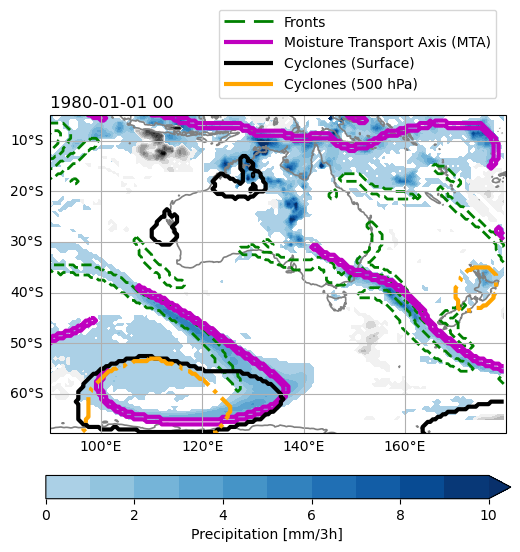

In [ ]:
wf_mapx = dict(
    F="Fronts",
    M="Moisture Transport Axis (MTA)",
    C="Cyclones (Surface)",
    V="Cyclones (500 hPa)",
    U="Unclassified",
)
mapcrs = ccrs.PlateCarree(central_longitude=0)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="w", subplot_kw={"projection": mapcrs})
# fig.subplots_adjust(hspace=0.4)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", lw=1.2)
ax.set_extent([90, 180, -60, -5])
ax.set_title(f"{dt.strftime('%Y-%m-%d %H')}", loc="left")
# Fronts (dashed)
cfF = ax.contour(
    df.longitude,
    df.latitude,
    df["F"].sel(time=t) * 1e3,
    colors="green",
    linestyles="--",
    linewidths=2,
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
# MTAs
cfM = ax.contour(
    df.longitude,
    df.latitude,
    df["M"].sel(time=t) * 1e3,
    colors="m",
    # linestyles="--",
    linewidths=3,
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
# Cyclones (black lines)
cfC = ax.contour(
    df.longitude,
    df.latitude,
    df["C"].sel(time=t) * 1e3,
    colors="black",
    levels=[1],
    alpha=1.0,
    linewidths=3,
    transform=datacrs,
)
# Cyclones (black lines)
cfV = ax.contour(
    df.longitude,
    df.latitude,
    df["V"].sel(time=t) * 1e3,
    colors="orange",
    linestyles="-.",
    levels=[1],
    alpha=1.0,
    linewidths=3,
    transform=datacrs,
)

orig_cmap = plt.cm.Blues
new_colors = orig_cmap(np.linspace(0.3, 1.0, 256))
cmap = LinearSegmentedColormap.from_list("truncated_viridis", new_colors)
cfT = ax.contourf(
    ds.longitude,
    ds.latitude,
    ds["total"].sel(time=t),
    # cmap=cmaps.MPL_jet,
    # cmap=cmaps.MPL_YlGnBu,
    # cmap=cmaps.MPL_Blues,
    cmap=cmap,
    levels=np.arange(0, 11),
    extend="max",
    alpha=1.0,
    transform=datacrs,
)

cfU = ax.contourf(
    ds.longitude,
    ds.latitude,
    ds["U"].sel(time=t),
    cmap="gray_r",
    levels=np.arange(0.1, 10),
    extend="max",
    alpha=1.0,
    transform=datacrs,
)
fig.colorbar(cfT, label="Precipitation [mm/3h]", orientation="horizontal", shrink=0.5, pad=0.1)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
artists = [cf.legend_elements()[0][0] for cf in [cfF, cfM, cfC, cfV]]
labels = [wf_mapx[var] for var in ["F", "M", "C", "V"]]
fig.legend(artists, labels, loc="lower right", bbox_to_anchor=(0.7, 0.9), handlelength=3.5)
plt.savefig(f"{path_fig}/snapshot_{t.strftime('%Y%m%d')}.png", dpi=300, bbox_inches="tight")

# Plot attribution

In [5]:
# dtlist = xr.date_range("1980-01-01", "2022-12-01", freq="1MS")
# cyc_minprominence=30
# def preprocess(ds):
#     """Preprocess the ERA5 dataset."""
#     # ds = ds.sel(latitude=slice(-33, -40), longitude=slice(140, 151))
#     ds = ds.sel(latitude=slice(-30, -45), longitude=slice(135, 155))
#     return ds

# files = [f"{path_attr}/ERA5_precip_attribution_{dt.strftime('%Y%m')}_aus_min{cyc_minprominence}gpm.nc" for dt in dtlist]
# ds = xr.open_mfdataset(files, chunks='auto', preprocess=preprocess)
# ds

# ds.attrs["history"] = ds.attrs["history"] + f"\n{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Combined timesteps and subset to region around Victoria, Australia."
# var_encoding = {"zlib": True, "complevel": 1}
# encoding = {var: var_encoding for var in ds.data_vars}
# ds.to_netcdf(f"{path_attr}/ERA5_precip_attribution_{dtlist[0].year}-{dtlist[-1].year}_vic_min{cyc_minprominence}gpm_zlib.nc", compute=True, encoding=encoding)
# ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 32144, latitude: 15, longitude: 23)
Coordinates:
  * time       (time) datetime64[ns] 257kB 1980-01-01 ... 1990-12-31T21:00:00
  * latitude   (latitude) float32 60B -33.0 -33.5 -34.0 ... -39.0 -39.5 -40.0
  * longitude  (longitude) float32 92B 140.0 140.5 141.0 ... 150.0 150.5 151.0
Data variables: (12/17)
    U          (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    M          (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    F          (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    FM         (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    V          (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    VM         (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    ...         ...
    CFM        (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    CV         (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    CVM        (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    CVF        (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    CVFM       (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
    total      (time, latitude, longitude) float64 89MB dask.array<chunksize=(248, 15, 23), meta=np.ndarray>
Attributes:
    description:  Precipitation attribution to weather features (cyclones, fr...
    history:      2026-09-14 15:39:48 by 1.6.1-7-g2e093da

In [ ]:
dtlist = xr.date_range("1980-01-01", "2022-12-01", freq="1MS")
cyc_minprominence = 30
ds = xr.open_dataset(
    f"{path_attr}/ERA5_precip_attribution_{dtlist[0].year}-{dtlist[-1].year}_vic_min{cyc_minprominence}gpm.nc",
    chunks="auto",
)
ds

<xarray.Dataset> Size: 22GB
Dimensions:    (time: 125648, latitude: 31, longitude: 41)
Coordinates:
  * time       (time) datetime64[ns] 1MB 1980-01-01 ... 2022-12-31T21:00:00
  * latitude   (latitude) float32 124B -30.0 -30.5 -31.0 ... -44.0 -44.5 -45.0
  * longitude  (longitude) float32 164B 135.0 135.5 136.0 ... 154.0 154.5 155.0
Data variables: (12/17)
    U          (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    M          (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    F          (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    FM         (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    V          (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    VM         (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    ...         ...
    CFM        (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    CV         (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    CVM        (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    CVF        (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    CVFM       (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
    total      (time, latitude, longitude) float64 1GB dask.array<chunksize=(63070, 14, 19), meta=np.ndarray>
Attributes:
    description:  Precipitation attribution to weather features (cyclones, fr...
    history:      2026-09-14 15:39:48 by 1.6.1-7-g2e093da\n2026-09-14 23:46:5...

In [ ]:
def format_ax(ax):

    ax.coastlines()
    ax.add_feature(cfeature.STATES)

    ax.set_extent([138, 153, -44, -33])
    ax.set_xticks(np.arange(140, 155, 5))
    ax.set_yticks(np.arange(-44, -30, 4))
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    return ax

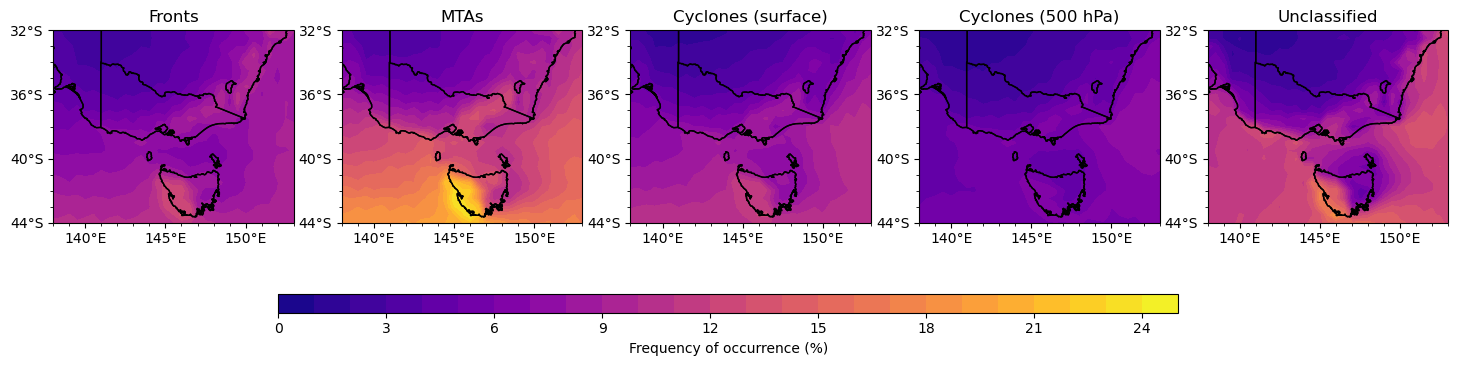

In [ ]:
# Plot the frequency of occurrence of feature (in any combo) at each grid point (%)
fig, axes = plt.subplots(
    1,
    5,
    figsize=(18, 3.8),
    sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)

axes = axes.flatten()
for i, (var, label) in enumerate(wf_map.items()):
    ax = axes[i]
    ax.set_title(label)
    # Sum over all variables that contain the letter
    freq = 0
    for v in [v for v in ds.data_vars if var in v]:
        freq += (ds[v] > 0).sum(dim="time")

    cm = ax.contourf(
        ds.longitude,
        ds.latitude,
        (freq / ds["time"].size) * 100,
        cmap="plasma",
        levels=np.arange(0, 26, 1),
    )
    ax = format_ax(ax)

plt.subplots_adjust(bottom=0.1)
cbar_ax = fig.add_axes([0.25, 00, 0.5, 0.05])  # [left, bottom, width, height]
cbar = fig.colorbar(cm, cax=cbar_ax, orientation="horizontal", extend="max")
cbar.set_label("Frequency of occurrence (%)")
plt.savefig(f"{path_fig}/frequency_features_aus.png", dpi=300, bbox_inches="tight")

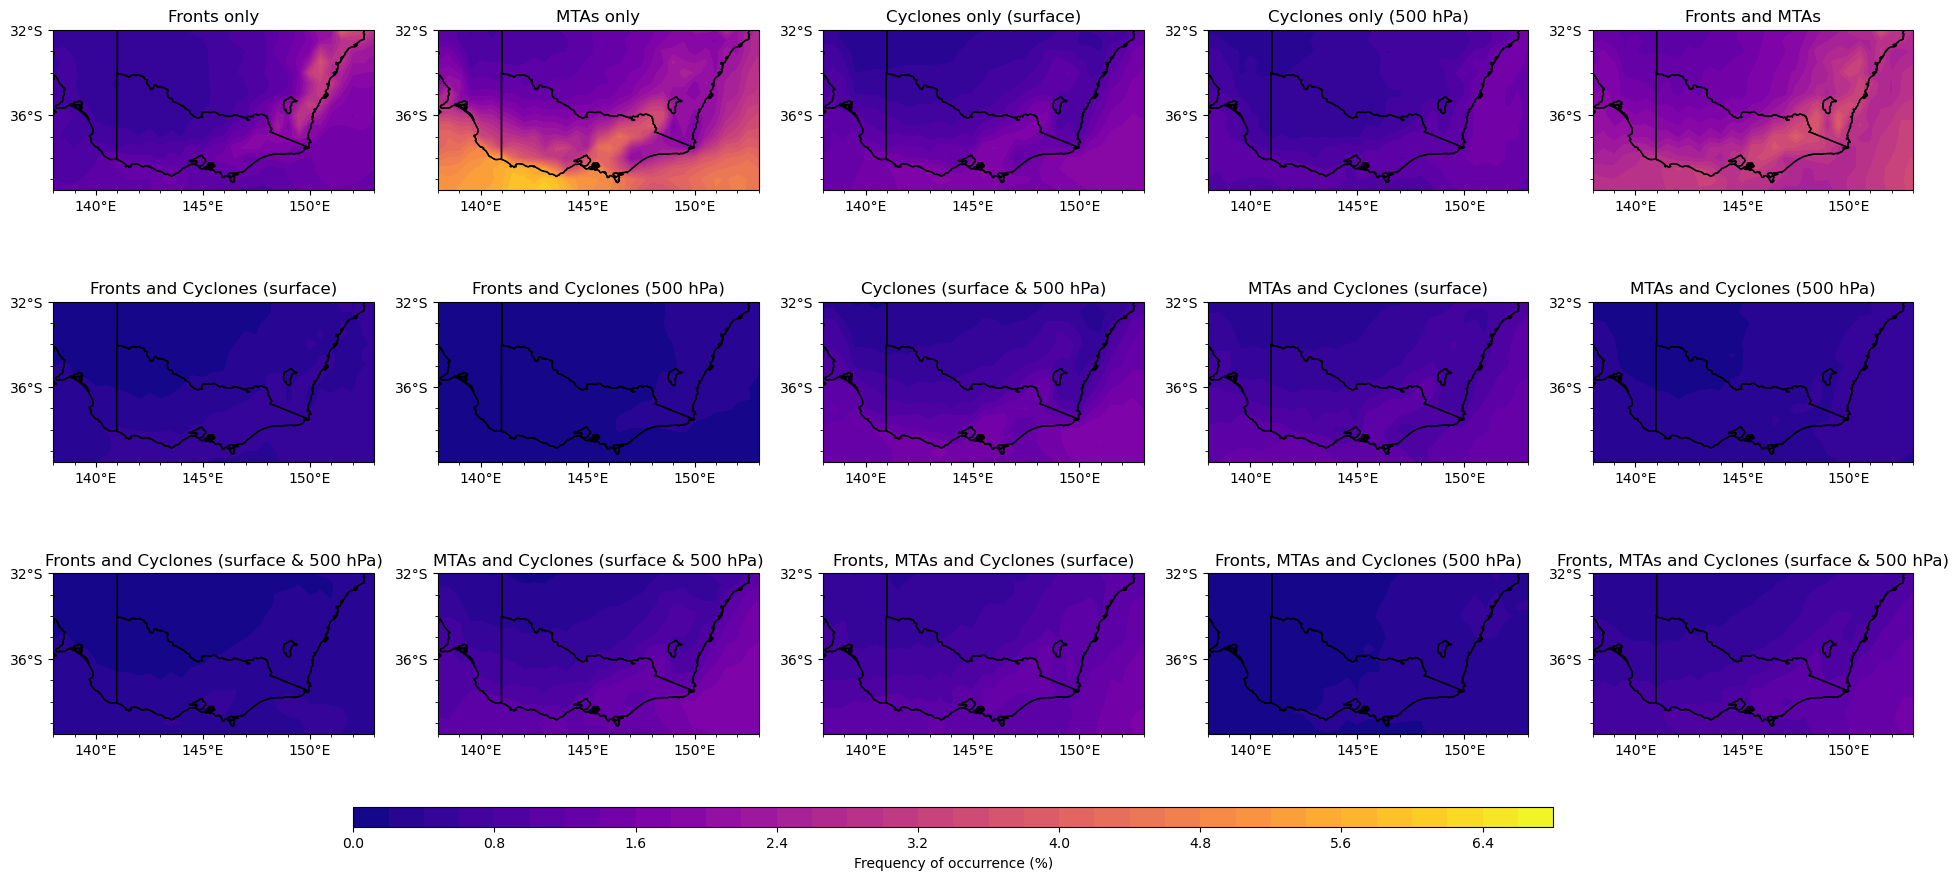

In [ ]:
# Plot the frequency of occurrence of each feature combo at each grid point (%)
fig, axes = plt.subplots(
    3,
    5,
    figsize=(24, 10),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()

for i, (var, label) in enumerate(var_map.items()):
    ax = axes[i]
    # if var == 'U':
    #     ax.set_visible(False)
    # else:
    ax.set_title(label)
    freq = (ds[var] > 0).sum(dim="time") / ds["time"].size
    cm = ax.contourf(
        ds.longitude, ds.latitude, freq * 100, cmap="plasma", levels=np.arange(0, 7, 0.2)
    )
    ax = format_ax(ax)
    ax.set_extent([138, 153, -39.5, -32])

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(cm, cax=cbar_ax, orientation="horizontal", extend="max")
cbar.set_label("Frequency of occurrence (%)")
plt.savefig(f"{path_fig}/frequency_feature_combos_aus.png", dpi=300, bbox_inches="tight")

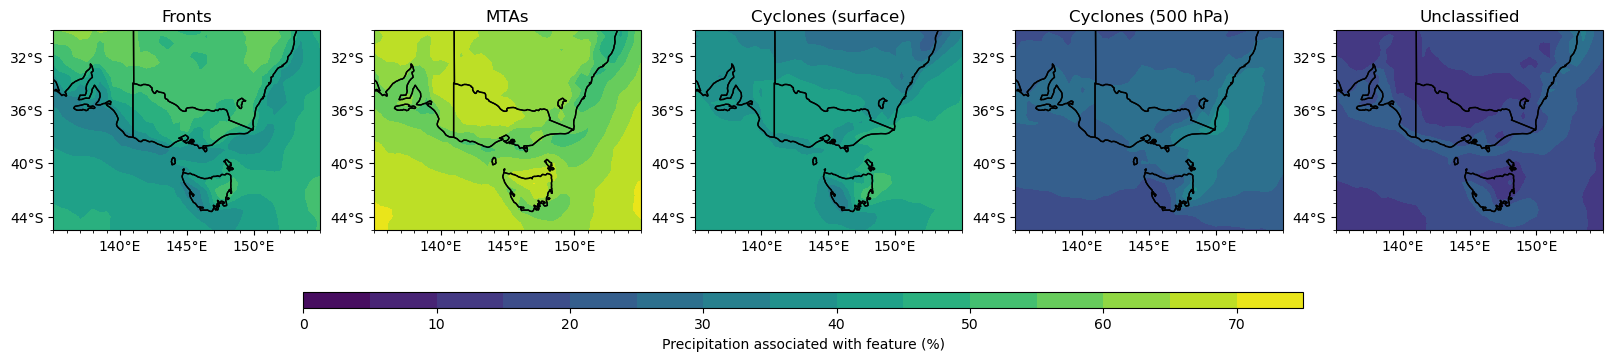

In [ ]:
# Relative contribution of feature to precipitation (%)
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()
for i, (var, label) in enumerate(wf_map.items()):
    ax = axes[i]
    ax.set_title(wf_map[var])
    freq = 0
    for v in [v for v in ds.data_vars if var in v]:
        freq += ds[v].sum(dim="time")

    cm = ax.contourf(
        ds.longitude,
        ds.latitude,
        (freq / ds["total"].sum(dim="time")) * 100,
        cmap="viridis",
        # cmap=cmaps.cmocean_dense,
        levels=np.arange(0, 80, 5),
    )
    ax = format_ax(ax)

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.04])
cbar = fig.colorbar(cm, cax=cbar_ax, orientation="horizontal", extend="max")
cbar.set_label("Precipitation associated with feature (%)")
plt.savefig(f"{path_fig}/feature_relative_contribution_aus.png", dpi=300, bbox_inches="tight")

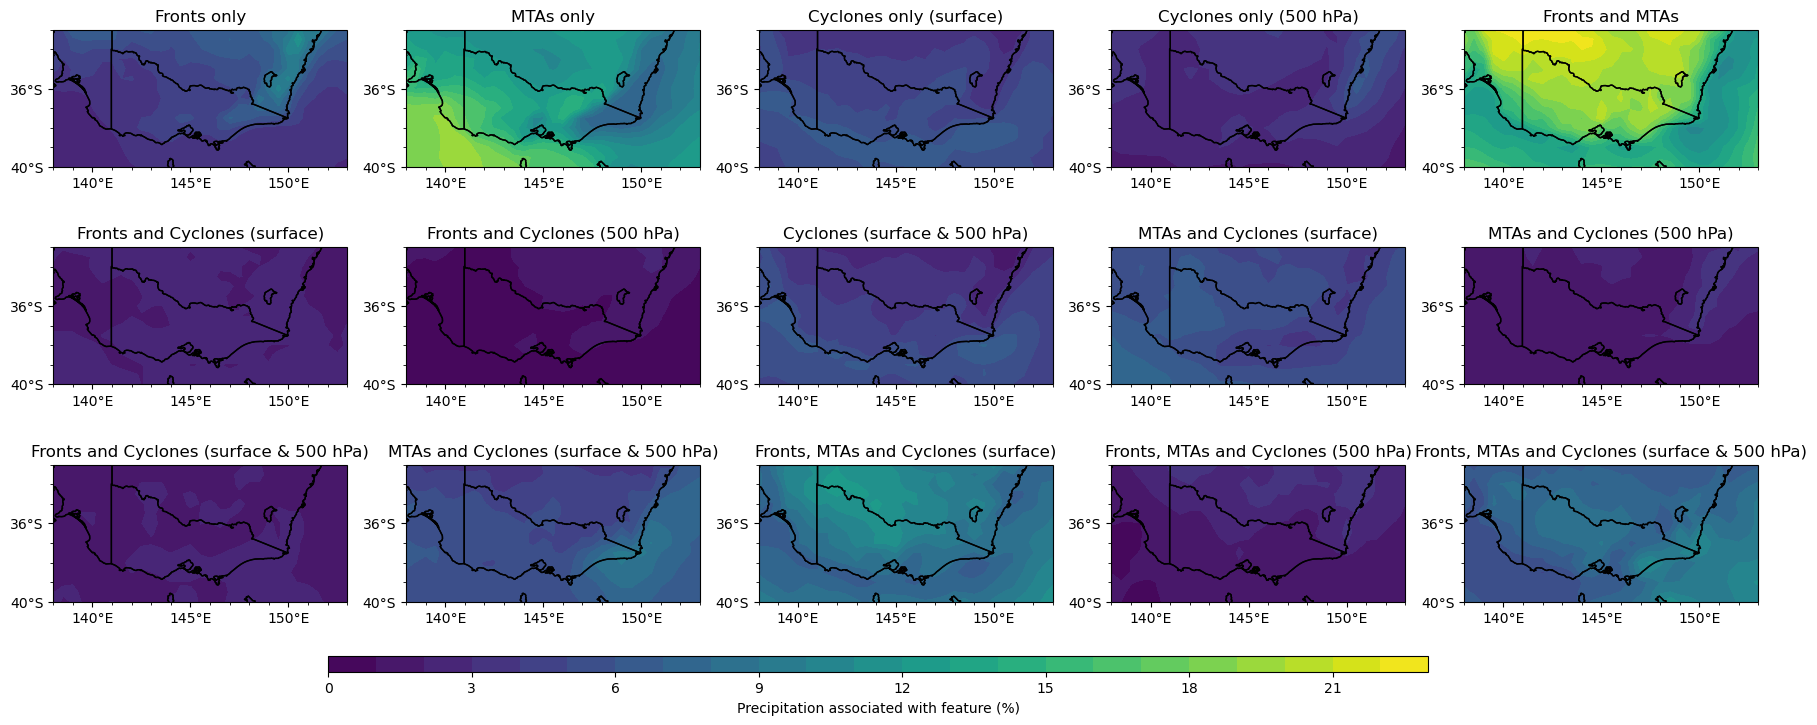

In [ ]:
# Relative contribution of feature to precipitation (%)
fig, axes = plt.subplots(
    3,
    5,
    figsize=(22, 8),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()

for i, (var, label) in enumerate(var_map.items()):
    ax = axes[i]
    ax.set_title(label)

    freq = ds[var].sum(dim="time") / ds["total"].sum(dim="time")
    cm = ax.contourf(
        ds.longitude,
        ds.latitude,
        freq * 100,
        # cmap="YlGnBu",
        cmap="viridis",
        levels=np.arange(0, 24, 1),
    )
    ax = format_ax(ax)
    ax.set_extent([138, 153, -40, -33])

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(cm, cax=cbar_ax, orientation="horizontal", extend=max)
cbar.set_label("Precipitation associated with feature (%)")
plt.savefig(
    f"{path_fig}/feature_relative_contribution_combos_aus.png", dpi=300, bbox_inches="tight"
)

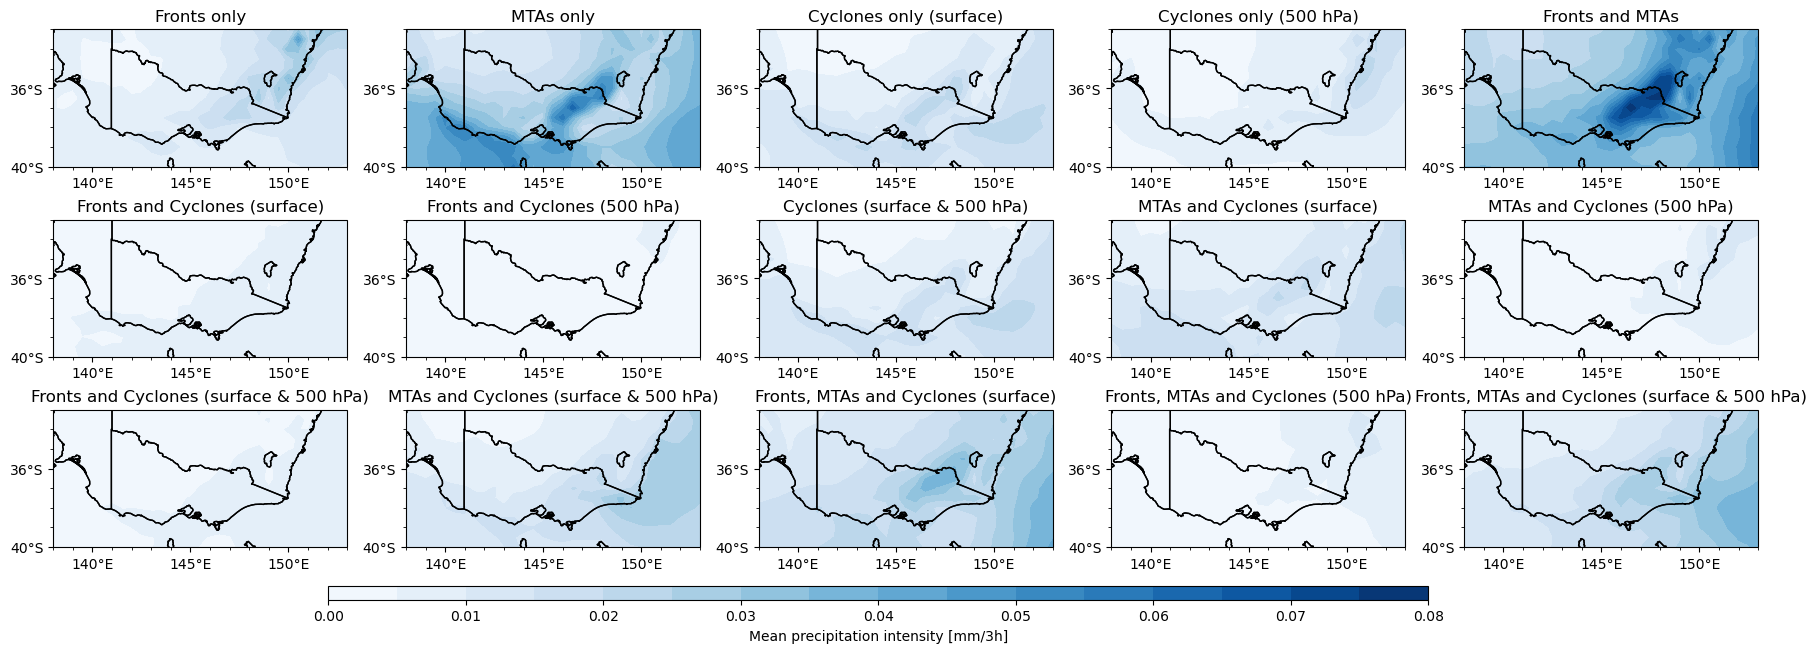

In [ ]:
# Relative contribution of feature to precipitation (%)
fig, axes = plt.subplots(
    3,
    5,
    figsize=(22, 7),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()

for i, (var, label) in enumerate(var_map.items()):
    ax = axes[i]
    ax.set_title(label)
    # mean =
    cm = ax.contourf(
        ds.longitude,
        ds.latitude,
        ds[var].mean(dim="time"),
        cmap="Blues",
        levels=np.arange(0, 0.085, 0.005),
    )
    ax = format_ax(ax)
    ax.set_extent([138, 153, -40, -33])

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(cm, cax=cbar_ax, orientation="horizontal", extend=max)
cbar.set_label("Mean precipitation intensity [mm/3h]")
plt.savefig(f"{path_fig}/feature_precip_intensity_combos_aus.png", dpi=300, bbox_inches="tight")